# EDA Dokumen Sirah Nabawiyah
**Fokus Analisis:** Mengeksplorasi **dokumen mentah** (buku referensi PDF/Teks).

*Catatan: Notebook ini berbeda dengan eda_dataset.ipynb. Notebook ini berfokus pada dokumen sumbernya (buku), sedangkan eda_dataset.ipynb berfokus pada analisis dataset Q&A yang dihasilkan.*

Notebook ini relevan untuk mendokumentasikan Bab 3.2 (Analisis Karakteristik Dokumen Sumber) — menjawab **mengapa ukuran chunk dipilih sekian**.

---

**Notebook ini menghasilkan:**
1. Statistik karakteristik dokumen (jumlah bab, subbab, karakter, halaman)
2. Distribusi panjang teks per subbab
3. Distribusi jumlah halaman per subbab
4. Jumlah subbab per bab
5. Distribusi panjang chunk (setelah segmentasi)


In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── PATH — sesuaikan jika berbeda ──────────────────────────────────────────
BASE_DIR    = os.path.normpath(os.path.join(os.getcwd(), "..", ".."))
DATA_DIR    = os.path.join(BASE_DIR, "data")

DOC_JSON    = os.path.join(DATA_DIR, "preprocess_result", "toc_result", "document_full_cleaned.json")
CHUNKS_JSON = os.path.join(DATA_DIR, "vectordb", "chunks_toc_baseline_BACKUP_CHUNK1000.json")
OUTPUT_DIR  = os.path.join(DATA_DIR, "eda_plots", "dokumen")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.dpi"       : 150,
})

COLORS = {
    "primary"  : "#2E86AB",
    "secondary": "#E84855",
    "accent"   : "#3BB273",
    "neutral"  : "#545775",
}

print("✅ Setup selesai.")
print(f"   DOC_JSON    : {DOC_JSON}")
print(f"   CHUNKS_JSON : {CHUNKS_JSON}")
print(f"   OUTPUT_DIR  : {OUTPUT_DIR}")

✅ Setup selesai.
   DOC_JSON    : c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\preprocess_result\toc_result\document_full_cleaned.json
   CHUNKS_JSON : c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\vectordb\chunks_toc_baseline_BACKUP_CHUNK1000.json
   OUTPUT_DIR  : c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen


## Cell 2 — Load & Parse Dokumen

In [2]:
with open(DOC_JSON, "r", encoding="utf-8") as f:
    document = json.load(f)

# Saring UNKNOWN BAB (halaman pembuka/kata pengantar)
bab_list = [b for b in document if b["bab_title"] != "UNKNOWN BAB"]

print(f"Total entri JSON (termasuk UNKNOWN BAB) : {len(document)}")
print(f"Bab utama (setelah filter)              : {len(bab_list)}")
print()
print("Contoh 3 nama bab pertama:")
for b in bab_list[:3]:
    print(f"  - {b['bab_title']}")

Total entri JSON (termasuk UNKNOWN BAB) : 61
Bab utama (setelah filter)              : 60

Contoh 3 nama bab pertama:
  - POSISI BANGSA ARAB DAN KAUMNYA
  - KEKUASAAN DAN IMARAH DI KALANGAN BANGSA ARAB
  - AGAMA BANGSA ARAB


## Cell 3 — Kalkulasi Statistik Dokumen

In [3]:
total_subbab       = 0
total_chars        = 0
total_words        = 0
total_pages_set    = set()

subbab_char_lengths = []
subbab_word_lengths = []
subbab_page_counts  = []
bab_subbab_counts   = []
bab_names           = []

for bab in bab_list:
    subbabs = bab.get("subbab", [])
    bab_subbab_counts.append(len(subbabs))
    bab_names.append(bab["bab_title"][:35])

    for sb in subbabs:
        total_subbab += 1
        text  = " ".join(sb.get("content", []))
        pages = sb.get("pages", [])

        char_len = len(text)
        word_len = len(text.split())

        total_chars += char_len
        total_words += word_len
        subbab_char_lengths.append(char_len)
        subbab_word_lengths.append(word_len)
        subbab_page_counts.append(len(pages))
        total_pages_set.update(pages)

total_pages = len(total_pages_set)

# Print tabel ringkasan
print("=" * 55)
print("  KARAKTERISTIK DOKUMEN SIRAH NABAWIYAH")
print("=" * 55)
rows = [
    ("Jumlah Bab Utama",          f"{len(bab_list)}"),
    ("Jumlah Subbab",             f"{total_subbab}"),
    ("Total Halaman (unik)",      f"{total_pages}"),
    ("Total Karakter",            f"{total_chars:,}"),
    ("Total Kata (estimasi)",     f"{total_words:,}"),
    ("Rata-rata karakter/subbab", f"{int(np.mean(subbab_char_lengths)):,}"),
    ("Median karakter/subbab",    f"{int(np.median(subbab_char_lengths)):,}"),
    ("Rata-rata halaman/subbab",  f"{np.mean(subbab_page_counts):.1f}"),
]
for label, val in rows:
    print(f"  {label:<30} : {val}")
print("=" * 55)

  KARAKTERISTIK DOKUMEN SIRAH NABAWIYAH
  Jumlah Bab Utama               : 60
  Jumlah Subbab                  : 390
  Total Halaman (unik)           : 600
  Total Karakter                 : 1,237,521
  Total Kata (estimasi)          : 173,471
  Rata-rata karakter/subbab      : 3,173
  Median karakter/subbab         : 1,966
  Rata-rata halaman/subbab       : 2.3


## Grafik 1 — Distribusi Panjang Teks per Subbab (Karakter)

Disimpan: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen\01_distribusi_panjang_subbab.png


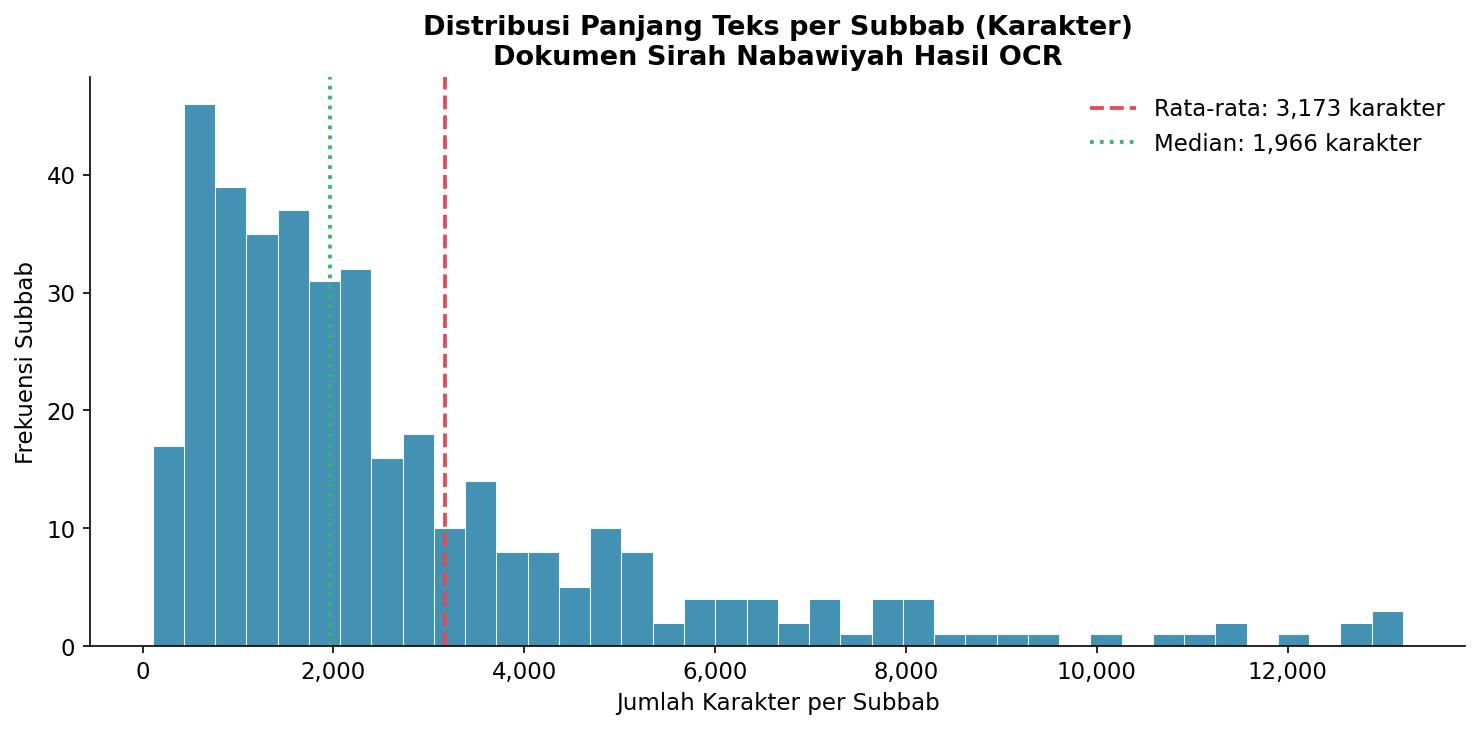

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

max_plot = np.percentile(subbab_char_lengths, 97)
filtered = [x for x in subbab_char_lengths if x <= max_plot]

ax.hist(filtered, bins=40, color=COLORS["primary"], edgecolor="white", linewidth=0.5, alpha=0.9)

mean_val   = np.mean(subbab_char_lengths)
median_val = np.median(subbab_char_lengths)

ax.axvline(mean_val,   color=COLORS["secondary"], linestyle="--", linewidth=1.8,
           label=f"Rata-rata: {mean_val:,.0f} karakter")
ax.axvline(median_val, color=COLORS["accent"],    linestyle=":",  linewidth=1.8,
           label=f"Median: {median_val:,.0f} karakter")

ax.set_title("Distribusi Panjang Teks per Subbab (Karakter)\nDokumen Sirah Nabawiyah Hasil OCR")
ax.set_xlabel("Jumlah Karakter per Subbab")
ax.set_ylabel("Frekuensi Subbab")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=False)
plt.tight_layout()

out = os.path.join(OUTPUT_DIR, "01_distribusi_panjang_subbab.png")
fig.savefig(out, bbox_inches="tight")
print(f"Disimpan: {out}")
plt.show()

## Grafik 2 — Distribusi Jumlah Halaman per Subbab

Disimpan: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen\02_distribusi_halaman_subbab.png


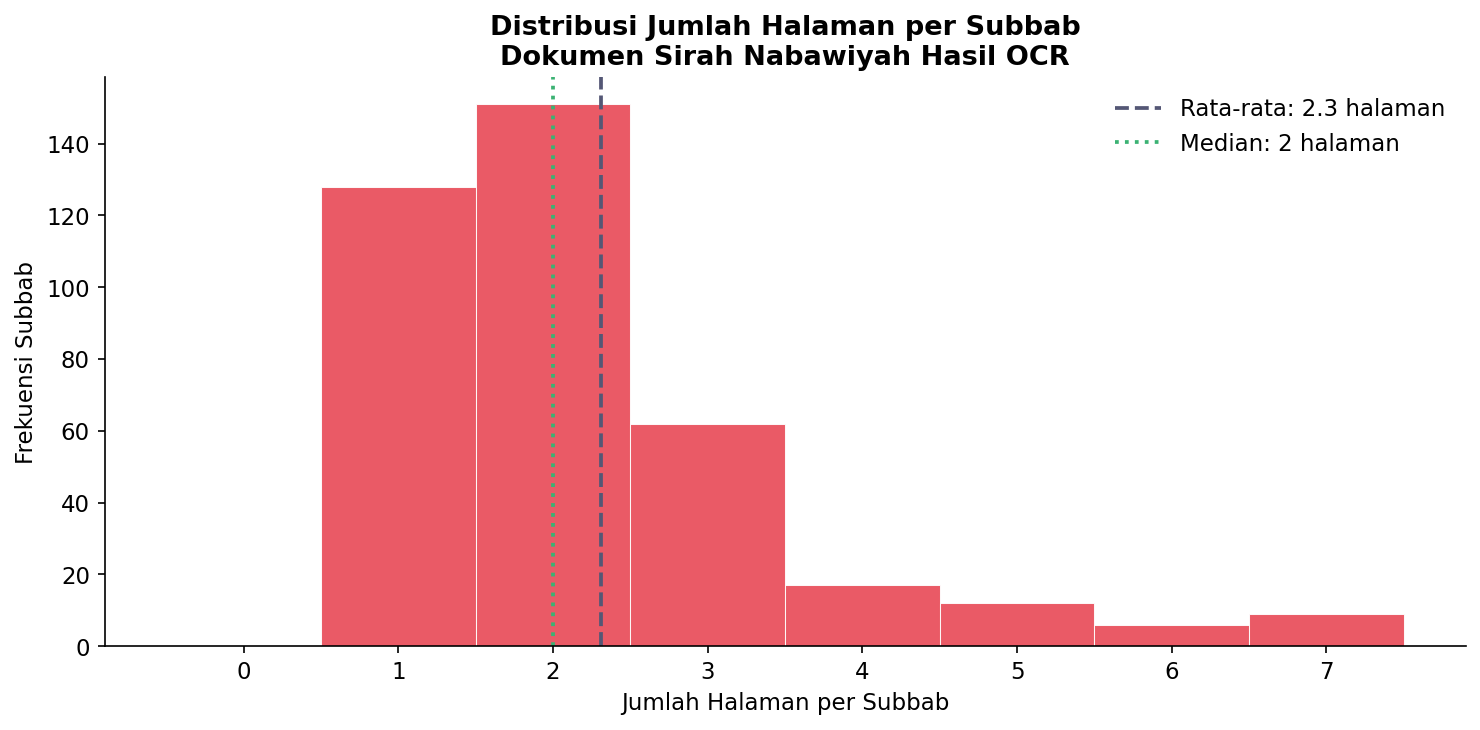

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

max_pages = int(np.percentile(subbab_page_counts, 97))
ax.hist(subbab_page_counts, bins=range(0, max_pages + 2), color=COLORS["secondary"],
        edgecolor="white", linewidth=0.5, alpha=0.9, align="left")

mean_p   = np.mean(subbab_page_counts)
median_p = np.median(subbab_page_counts)

ax.axvline(mean_p,   color=COLORS["neutral"], linestyle="--", linewidth=1.8,
           label=f"Rata-rata: {mean_p:.1f} halaman")
ax.axvline(median_p, color=COLORS["accent"],  linestyle=":",  linewidth=1.8,
           label=f"Median: {int(median_p)} halaman")

ax.set_title("Distribusi Jumlah Halaman per Subbab\nDokumen Sirah Nabawiyah Hasil OCR")
ax.set_xlabel("Jumlah Halaman per Subbab")
ax.set_ylabel("Frekuensi Subbab")
ax.legend(frameon=False)
plt.tight_layout()

out = os.path.join(OUTPUT_DIR, "02_distribusi_halaman_subbab.png")
fig.savefig(out, bbox_inches="tight")
print(f"Disimpan: {out}")
plt.show()

## Grafik 3 — Jumlah Subbab per Bab

Disimpan: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen\03_subbab_per_bab.png


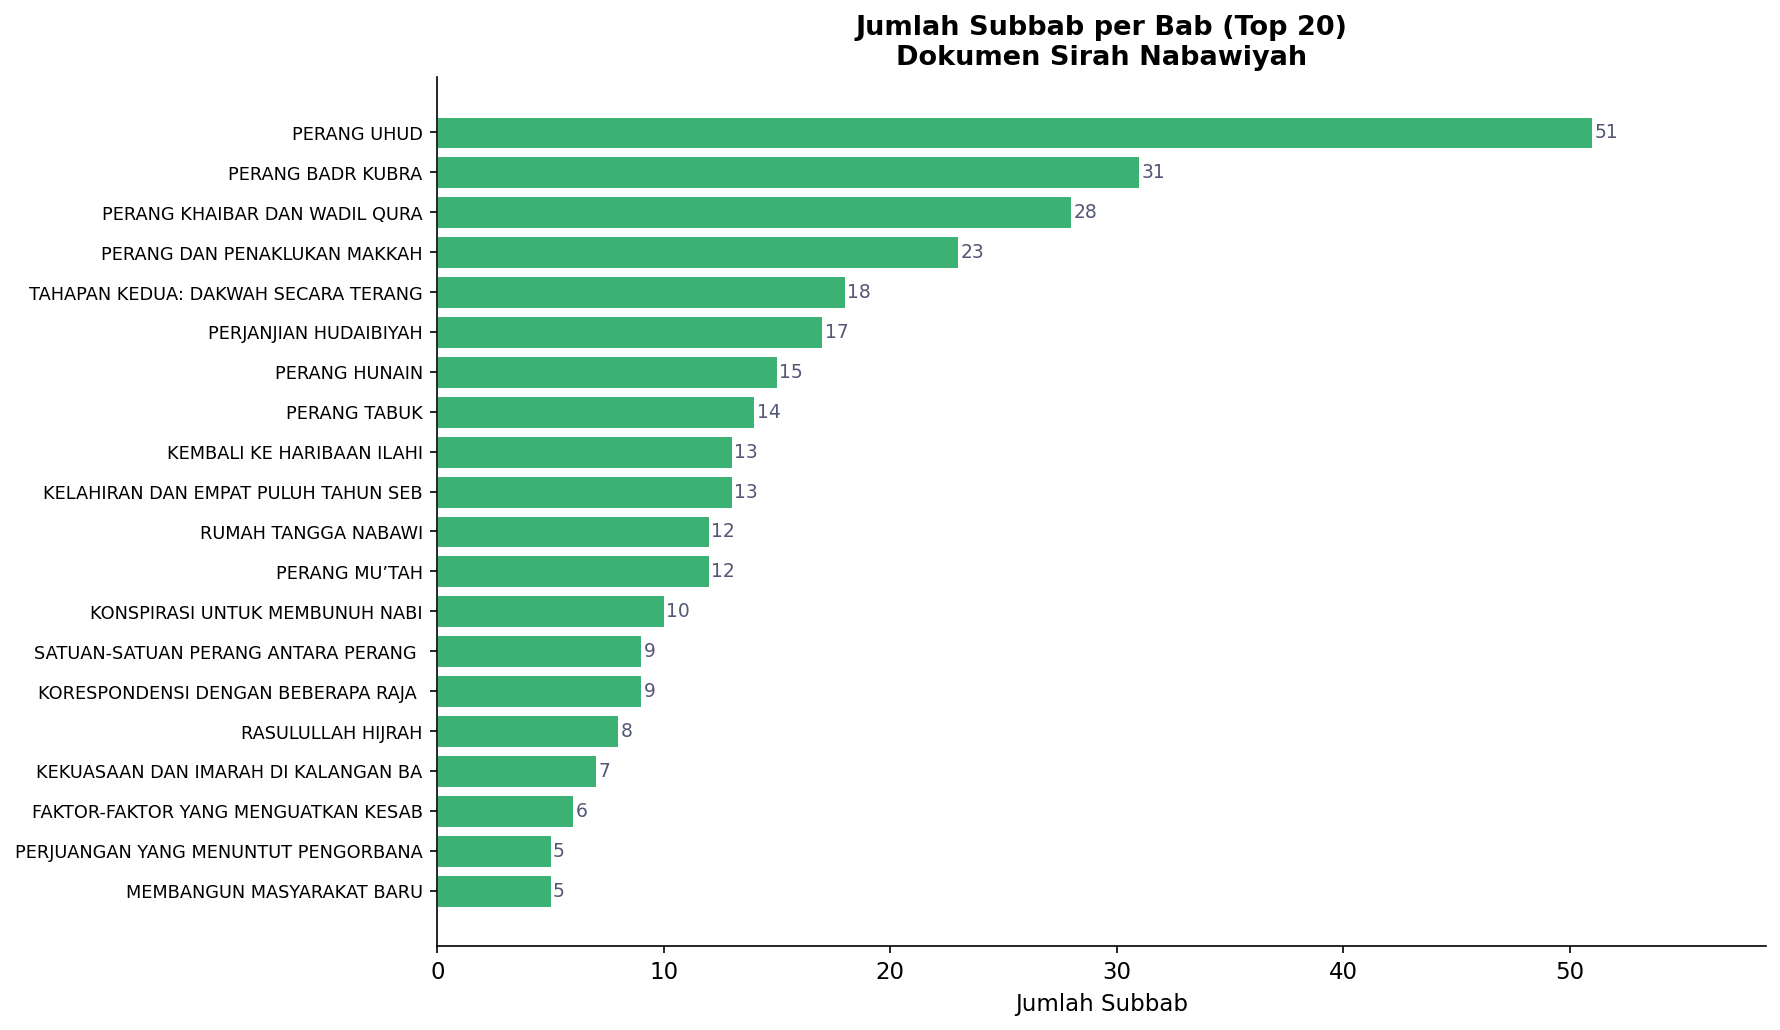

In [6]:
sorted_pairs = sorted(zip(bab_subbab_counts, bab_names), reverse=True)
top_n = min(20, len(sorted_pairs))
top_counts, top_names = zip(*sorted_pairs[:top_n])

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(range(top_n), top_counts, color=COLORS["accent"], edgecolor="white", linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels([n.upper() for n in top_names], fontsize=8.5)
ax.invert_yaxis()

for bar, val in zip(bars, top_counts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", ha="left", fontsize=9, color=COLORS["neutral"])

ax.set_title(f"Jumlah Subbab per Bab (Top {top_n})\nDokumen Sirah Nabawiyah")
ax.set_xlabel("Jumlah Subbab")
ax.set_xlim(0, max(top_counts) * 1.15)
plt.tight_layout()

out = os.path.join(OUTPUT_DIR, "03_subbab_per_bab.png")
fig.savefig(out, bbox_inches="tight")
print(f"Disimpan: {out}")
plt.show()

## Grafik 4 — Distribusi Panjang Chunk (Setelah Segmentasi)

Total chunk              : 1,901
Rata-rata karakter/chunk : 781
Median karakter/chunk    : 848
Rata-rata kata/chunk     : 109
Median kata/chunk        : 118
Disimpan: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen\04_distribusi_panjang_chunk.png


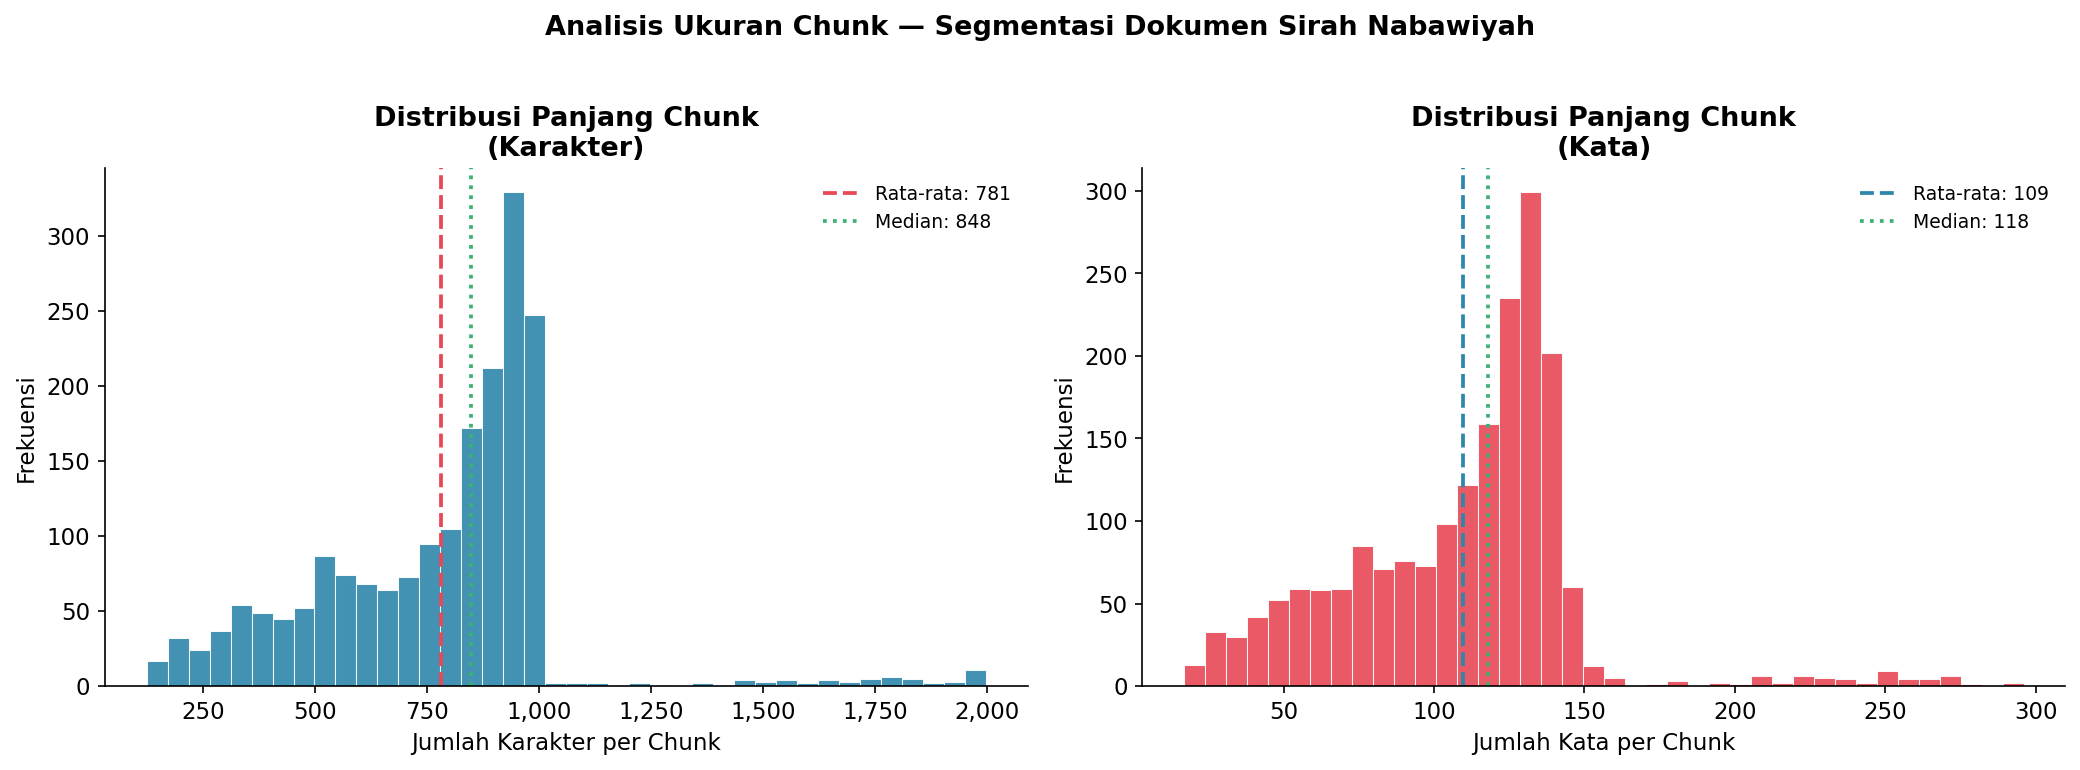

In [7]:
if not os.path.exists(CHUNKS_JSON):
    print(f"⚠️  File chunks tidak ditemukan: {CHUNKS_JSON}")
    print("    Lewati cell ini.")
else:
    with open(CHUNKS_JSON, "r", encoding="utf-8") as f:
        chunks = json.load(f)

    chunk_char_lengths = [len(c["text"]) for c in chunks]
    chunk_word_lengths = [len(c["text"].split()) for c in chunks]

    print(f"Total chunk              : {len(chunks):,}")
    print(f"Rata-rata karakter/chunk : {int(np.mean(chunk_char_lengths)):,}")
    print(f"Median karakter/chunk    : {int(np.median(chunk_char_lengths)):,}")
    print(f"Rata-rata kata/chunk     : {int(np.mean(chunk_word_lengths)):,}")
    print(f"Median kata/chunk        : {int(np.median(chunk_word_lengths)):,}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.hist(chunk_char_lengths, bins=40, color=COLORS["primary"],
            edgecolor="white", linewidth=0.5, alpha=0.9)
    ax.axvline(np.mean(chunk_char_lengths),   color=COLORS["secondary"], linestyle="--",
               linewidth=1.8, label=f"Rata-rata: {np.mean(chunk_char_lengths):,.0f}")
    ax.axvline(np.median(chunk_char_lengths), color=COLORS["accent"],    linestyle=":",
               linewidth=1.8, label=f"Median: {np.median(chunk_char_lengths):,.0f}")
    ax.set_title("Distribusi Panjang Chunk\n(Karakter)")
    ax.set_xlabel("Jumlah Karakter per Chunk")
    ax.set_ylabel("Frekuensi")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(frameon=False, fontsize=9)

    ax = axes[1]
    ax.hist(chunk_word_lengths, bins=40, color=COLORS["secondary"],
            edgecolor="white", linewidth=0.5, alpha=0.9)
    ax.axvline(np.mean(chunk_word_lengths),   color=COLORS["primary"], linestyle="--",
               linewidth=1.8, label=f"Rata-rata: {np.mean(chunk_word_lengths):,.0f}")
    ax.axvline(np.median(chunk_word_lengths), color=COLORS["accent"],  linestyle=":",
               linewidth=1.8, label=f"Median: {np.median(chunk_word_lengths):,.0f}")
    ax.set_title("Distribusi Panjang Chunk\n(Kata)")
    ax.set_xlabel("Jumlah Kata per Chunk")
    ax.set_ylabel("Frekuensi")
    ax.legend(frameon=False, fontsize=9)

    fig.suptitle("Analisis Ukuran Chunk — Segmentasi Dokumen Sirah Nabawiyah",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()

    out = os.path.join(OUTPUT_DIR, "04_distribusi_panjang_chunk.png")
    fig.savefig(out, bbox_inches="tight")
    print(f"Disimpan: {out}")
    plt.show()

## Ringkasan — Angka untuk Tabel 3.3 Skripsi

In [8]:
print("=" * 55)
print("  ANGKA SIAP PAKAI UNTUK TABEL 3.3 (BAB 3.2)")
print("=" * 55)
rows = [
    ("Jumlah halaman",                 f"{total_pages}"),
    ("Jumlah bab",                     f"{len(bab_list)}"),
    ("Jumlah subbab",                  f"{total_subbab}"),
    ("Total karakter (pasca-cleaning)",f"{total_chars:,}"),
    ("Total kata (estimasi)",          f"{total_words:,}"),
    ("Rata-rata karakter / subbab",    f"{int(np.mean(subbab_char_lengths)):,}"),
    ("Rata-rata halaman / subbab",     f"{np.mean(subbab_page_counts):.1f}"),
    ("Bahasa",                         "Indonesia (terjemahan)"),
    ("Format sumber",                  "PDF berbasis citra (OCR)"),
]
for label, val in rows:
    print(f"  {label:<35} : {val}")
print("=" * 55)
print(f"\n✅ Semua grafik tersimpan di: {OUTPUT_DIR}")

  ANGKA SIAP PAKAI UNTUK TABEL 3.3 (BAB 3.2)
  Jumlah halaman                      : 600
  Jumlah bab                          : 60
  Jumlah subbab                       : 390
  Total karakter (pasca-cleaning)     : 1,237,521
  Total kata (estimasi)               : 173,471
  Rata-rata karakter / subbab         : 3,173
  Rata-rata halaman / subbab          : 2.3
  Bahasa                              : Indonesia (terjemahan)
  Format sumber                       : PDF berbasis citra (OCR)

✅ Semua grafik tersimpan di: c:\Users\Awalludin\OneDrive - PT. Telekomunikasi Indonesia\Documents\Aulia\TA NLP\TA_preprocess\TA_sirah\data\eda_plots\dokumen
